In [89]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [90]:
def read_collision_data_complete(filename):
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    sections = {}
    data_rows = []
    similarity_values = []
    snp_rate = []

    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        if line.startswith(':1:'):
            sections['test_name'] = line[3:].strip()
        elif line.startswith(':2:'):
            sections['column_headers'] = line[3:].strip().split(',')
        elif line.startswith(':3:'):
            line_content = line[3:].strip()
            line_parts = line_content.split(',')
            sections['Hashname'] = line_parts[0].strip()
            sections['SequenceLength'] = int(line_parts[1].strip())
            sections['TokenLength'] = int(line_parts[2].strip())
            sections['Distance_Metric'] = int(line_parts[3].strip())
        elif line.startswith(':4:'):
            line_content = line[3:].strip()
            similarity_values = [float(x.strip()) for x in line_content.split(',')]
            sections['similarity_values'] = similarity_values
        elif line.startswith(':5:'):
            line_content = line[3:].strip()
            snp_rate = [float(x.strip()) for x in line_content.split(',')]
            sections['snp_rate'] = snp_rate
        elif line.startswith(':6:'):
            line_content = line[3:].strip()
            collision_rates = [float(x.strip()) for x in line_content.split(',')]
            sections['collision_rates'] = collision_rates
            
            # Create data row
            row_data = {
                'test_name': sections.get('test_name', ''),
                'hashname': sections.get('Hashname', ''),
                'sequencelength': sections.get('SequenceLength', 0),
                'tokenlength': sections.get('TokenLength', 0),
                'similarity_values': similarity_values,
                'snp_rate': snp_rate,
                'collision_rates': collision_rates
            }
            data_rows.append(row_data)
    
    return sections, pd.DataFrame(data_rows)


In [97]:
# sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_OneBaseSamplingHash-32.csv")
# sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_MinHash-32.csv")
sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_SimHash-Ang-32.csv")

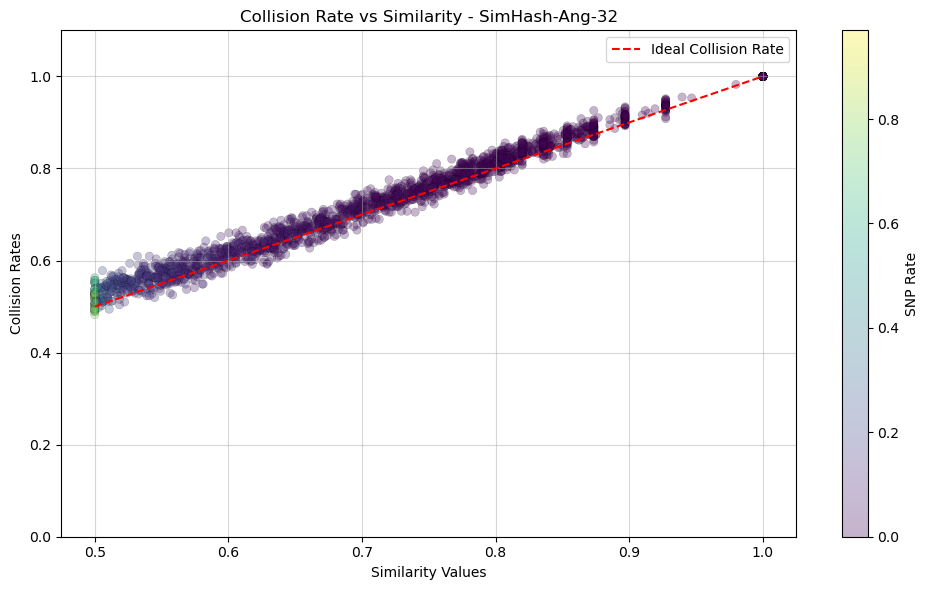

In [98]:
for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    label_values = row['snp_rate']
    plt.figure(figsize=(10, 6))
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.5)
    plt.scatter(x_values, y_values, c=label_values, cmap='viridis', alpha=0.3, edgecolors='black', linewidth=0.3)
    plt.colorbar(label='SNP Rate')
    plt.xlabel('Similarity Values')
    plt.ylabel('Collision Rates')
    plt.title(f"Collision Rate vs Similarity - {row['hashname']}")
    plt.plot([0.5, 1], [0.5, 1], 'r--', label='Ideal Collision Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

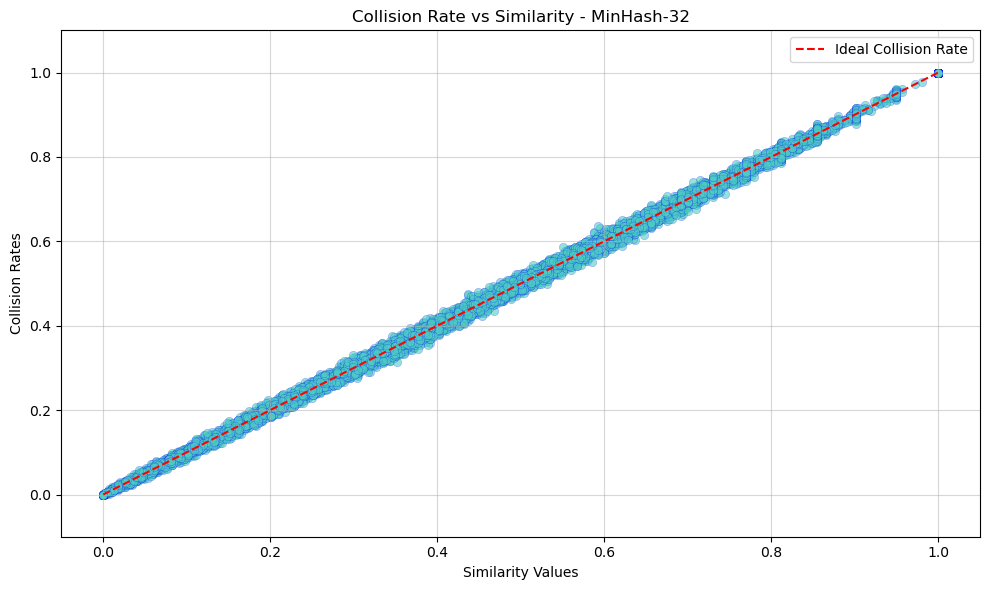

In [96]:
    # family_colors = ['#FF6B6B', '#4ECDC4', '#FFA07A']
for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    label_values = row['snp_rate']
    plt.figure(figsize=(10, 6))
    plt.ylim(-0.1, 1.1)
    plt.grid(True, alpha=0.5)
    plt.scatter(x_values, y_values, alpha=0.6,c='#4ECDC4', edgecolors='blue', linewidth=0.2)
    plt.xlabel('Similarity Values')
    plt.ylabel('Collision Rates')
    plt.title(f"Collision Rate vs Similarity - {row['hashname']}")
    plt.plot([0.0, 1], [0.0, 1], 'r--', label='Ideal Collision Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

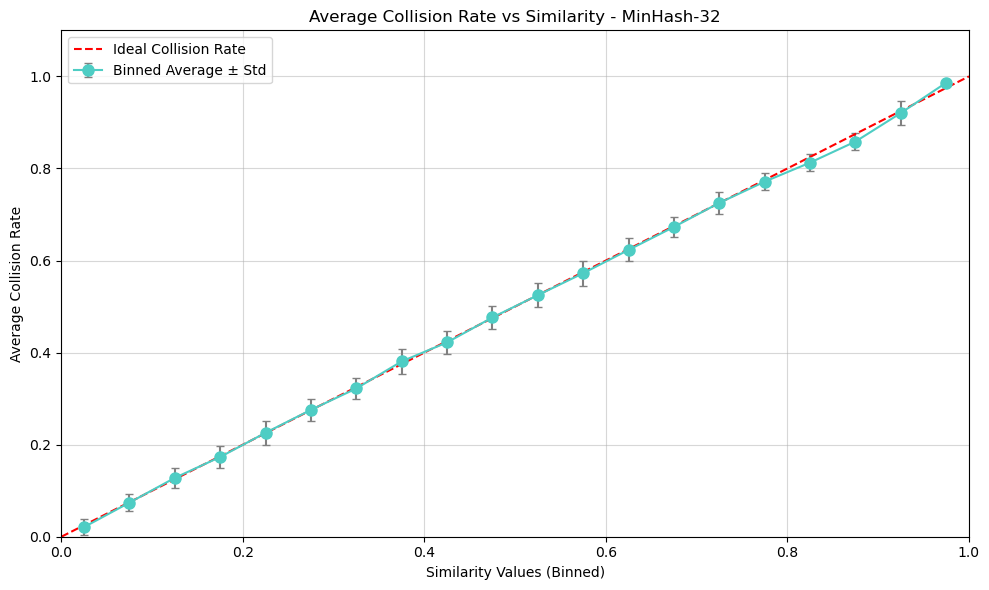

In [88]:
# Cell #VSC-9fa56913

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins (e.g., 20 bins from 0 to 1)
    num_bins = 20
    bin_edges = np.linspace(0, 1, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute mean and std for each bin
    bin_means = []
    bin_stds = []
    bin_counts = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
            bin_stds.append(np.std(y_values[mask]))
            bin_counts.append(mask.sum())
        else:
            bin_means.append(np.nan)
            bin_stds.append(np.nan)
            bin_counts.append(0)
    
    bin_means = np.array(bin_means)
    bin_stds = np.array(bin_stds)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.ylim(0, 1.1)
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.5)
    
    # Plot average with error bars (std deviation)
    plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', 
                 color='#4ECDC4', ecolor='gray', capsize=3, 
                 label='Binned Average ± Std', markersize=8)
    
    # Ideal line
    plt.plot([0, 1], [0, 1], 'r--', label='Ideal Collision Rate')
    
    plt.xlabel('Similarity Values (Binned)')
    plt.ylabel('Average Collision Rate')
    plt.title(f"Average Collision Rate vs Similarity - {row['hashname']}")
    plt.legend()
    plt.tight_layout()
    plt.show()